In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import os

sns.set_theme(style="whitegrid")

In [5]:
import pandas as pd


df = pd.read_csv('../Imdb_Movie_Dataset.csv', on_bad_lines='skip')
df_aux = df.copy()
media_votos = df_aux['vote_count'].mean()

df_nicho = df_aux[
    (df_aux['vote_count'] < media_votos) &
    (df_aux['vote_count'] > 20) &
    (df_aux['runtime'] > 0)
].copy()

df.head(10)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,7/15/2010,825532764,148,False,160000000,...,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,11/5/2014,701729206,169,False,165000000,...,en,Interstellar,The adventures of a group of explorers who mak...,140.241,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,7/16/2008,1004558444,152,False,185000000,...,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,12/15/2009,2923706026,162,False,237000000,...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,4/25/2012,1518815515,143,False,220000000,...,en,The Avengers,When an unexpected enemy emerges and threatens...,98.082,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."
5,293660,Deadpool,7.606,28894,Released,2/9/2016,783100000,108,False,58000000,...,en,Deadpool,The origin story of former Special Forces oper...,72.735,Witness the beginning of a happy ending.,"Action, Adventure, Comedy","20th Century Fox, The Donners' Company, Genre ...",United States of America,English,"superhero, anti hero, mercenary, based on comi..."
6,299536,Avengers: Infinity War,8.255,27713,Released,4/25/2018,2052415039,149,False,300000000,...,en,Avengers: Infinity War,As the Avengers and their allies have continue...,154.340,An entire universe. Once and for all.,"Adventure, Action, Science Fiction",Marvel Studios,United States of America,"English, Xhosa","sacrifice, magic, superhero, based on comic, s..."
7,550,Fight Club,8.438,27238,Released,10/15/1999,100853753,139,False,63000000,...,en,Fight Club,A ticking-time-bomb insomniac and a slippery s...,69.498,Mischief. Mayhem. Soap.,Drama,"Regency Enterprises, Fox 2000 Pictures, Taurus...",United States of America,English,"dual identity, rage and hate, based on novel o..."
8,118340,Guardians of the Galaxy,7.906,26638,Released,7/30/2014,772776600,121,False,170000000,...,en,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",33.255,All heroes start somewhere.,"Action, Science Fiction, Adventure",Marvel Studios,United States of America,English,"spacecraft, based on comic, space, orphan, adv..."
9,680,Pulp Fiction,8.488,25893,Released,9/10/1994,213900000,154,False,8500000,...,en,Pulp Fiction,"A burger-loving hit man, his philosophical par...",74.862,Just because you are a character doesn't mean ...,"Thriller, Crime","Miramax, A Band Apart, Jersey Films",United States of America,"English, Spanish, French","drug dealer, boxer, massage, stolen money, bri..."


In [3]:
df.columns = [c.strip().lower() for c in df.columns]
col_votos = 'vote_count' if 'vote_count' in df.columns else [c for c in df.columns if 'vote' in c][0]
df = df.dropna(subset=[col_votos])
df_sorted = df.sort_values(by=col_votos, ascending=False).reset_index(drop=True)
df_sorted['Ranking'] = range(1, len(df_sorted) + 1)

In [4]:
media_global = df_sorted[col_votos].mean()
corte_index = len(df_sorted[df_sorted[col_votos] >= media_global])

print(f"Total de filmes: {len(df_sorted):,}")
print(f"Média Global: {media_global:.2f} votos")
print(f"Ponto de Corte (Ranking): {corte_index:,}")

Total de filmes: 951,555
Média Global: 22.51 votos
Ponto de Corte (Ranking): 46,038


In [5]:
df_head = df_sorted[df_sorted['Ranking'] <= corte_index]
df_tail = df_sorted[df_sorted['Ranking'] > corte_index]

# Filtrando apenas filmes com votos para calcular a média de avaliação crítica
media_critica_head = df_head[df_head[col_votos] > 0]['vote_average'].mean()
media_critica_tail = df_tail[df_tail[col_votos] > 0]['vote_average'].mean()

print(f"Média de avaliação crítica (vote_average) para filmes da Cabeça (com votos): {media_critica_head:.2f}")
print(f"Média de avaliação crítica (vote_average) para filmes da Cauda Longa (com votos): {media_critica_tail:.2f}")

if media_critica_tail < media_critica_head:
    print("\nA recepção crítica dos filmes da Cauda Longa é ligeiramente inferior à dos filmes da Cabeça, sugerindo que, em média, a menor popularidade pode estar associada a uma qualidade percebida um pouco mais baixa.")
elif media_critica_tail > media_critica_head:
    print("\nA recepção crítica dos filmes da Cauda Longa é ligeiramente superior à dos filmes da Cabeça, o que sugere que a baixa popularidade não está necessariamente ligada a uma baixa qualidade.")
else:
    print("\nA recepção crítica dos filmes da Cauda Longa é similar à dos filmes da Cabeça, indicando que a baixa popularidade não está correlacionada com uma baixa qualidade percebida.")


Média de avaliação crítica (vote_average) para filmes da Cabeça (com votos): 6.29
Média de avaliação crítica (vote_average) para filmes da Cauda Longa (com votos): 5.97

A recepção crítica dos filmes da Cauda Longa é ligeiramente inferior à dos filmes da Cabeça, sugerindo que, em média, a menor popularidade pode estar associada a uma qualidade percebida um pouco mais baixa.


In [6]:
import plotly.express as px
import pandas as pd
import numpy as np # Import numpy for tick generation

filmes_cauda_longa_alta_nota = df_tail[df_tail['vote_average'] > 7]
filmes_head_alta_nota = df_head[df_head['vote_average'] > 7]

# Calculate films with 0 votes in each segment
df_head_zero_votes = df_head[df_head[col_votos] == 0]
df_tail_zero_votes = df_tail[df_tail[col_votos] == 0]

# Prepare data for Plotly grouped bar chart with requested categories
data_grouped = {
    'Segmento': [
        'Cauda Longa', 'Cauda Longa', 'Cauda Longa',
        'Cabeça', 'Cabeça', 'Cabeça' # Added 'Cabeça' for zero votes
    ],
    'Categoria': [
        'Total de Filmes', 'Filmes com 0 Votos', 'Filmes com Avaliação > 7',
        'Total de Filmes', 'Filmes com 0 Votos', 'Filmes com Avaliação > 7' # Added 'Filmes com 0 Votos' for Cabeça
    ],
    'Quantidade': [
        len(df_tail),                          # Cauda Longa: Total de Filmes
        len(df_tail_zero_votes),               # Cauda Longa: Filmes com 0 Votos
        len(filmes_cauda_longa_alta_nota),     # Cauda Longa: Filmes > 7
        len(df_head),                          # Cabeça: Total de Filmes
        len(df_head_zero_votes),               # Cabeça: Filmes com 0 Votos (which is 0)
        len(filmes_head_alta_nota)             # Cabeça: Filmes > 7
    ]
}
df_plot_grouped = pd.DataFrame(data_grouped)

# Removed filtering to explicitly show 'Filmes com 0 Votos' for Cabeça, even if 0
df_plot_grouped_filtered = df_plot_grouped.copy()

# Calculate percentages for annotations
df_plot_grouped_filtered['Percentage_Label'] = ''

total_cauda_longa_count = len(df_tail)
total_head_count = len(df_head)

def format_quantity(num):
    if num >= 1000:
        return f'{num/1000:.0f}k'
    return f'{num:,}'

def assign_percentage_grouped(row):
    if row['Segmento'] == 'Cauda Longa':
        total = total_cauda_longa_count
    else: # Cabeça
        total = total_head_count

    if row['Categoria'] == 'Total de Filmes':
        return format_quantity(row["Quantidade"]) if total > 0 else '' # Only quantity, abbreviated if large
    elif total > 0:
        percentage = (row["Quantidade"] / total) * 100
        return f'{format_quantity(row["Quantidade"])}({percentage:.2f}%)'
    return ''

df_plot_grouped_filtered['Percentage_Label'] = df_plot_grouped_filtered.apply(assign_percentage_grouped, axis=1)

# Create the Plotly grouped bar chart
fig = px.bar(
    df_plot_grouped_filtered,
    x='Segmento',
    y='Quantidade',
    color='Categoria',
    barmode='group',
    text='Percentage_Label',
    title='Composição de Filmes por Segmento (Total, Alta Avaliação e Sem Votos)',
    labels={
        'Quantidade': 'Quantidade de Filmes'
    },
    color_discrete_map={
        'Total de Filmes': 'gray',
        'Filmes com Avaliação > 7': 'royalblue',
        'Filmes com 0 Votos': 'firebrick'
    },
    category_orders={
        'Segmento': ['Cabeça', 'Cauda Longa'], # Invert the order here
        'Categoria': ['Total de Filmes', 'Filmes com 0 Votos', 'Filmes com Avaliação > 7']
    }
)

# --- Custom Y-axis formatting ---
y_max = df_plot_grouped_filtered['Quantidade'].max()
y_min = df_plot_grouped_filtered['Quantidade'].min()

# Adjust tick interval to ensure all hundreds of thousands are displayed if applicable
if y_max > 200000: # If the max value is in hundreds of thousands, ensure 100k intervals
    tick_interval = 100000
elif y_max > 20000: # If max value is in tens of thousands, ensure 10k intervals
    tick_interval = 10000
elif y_max > 2000: # If max value is in thousands, ensure 1k intervals
    tick_interval = 1000
else: # For smaller values, aim for 100s, rounded up based on a raw interval
    num_desired_ticks = 7
    tick_interval_raw = (y_max - y_min) / num_desired_ticks
    tick_interval = max(100, (round(tick_interval_raw / 100) + 1) * 100)

tick_vals = np.arange(0, y_max + tick_interval, tick_interval)
tick_text = [format_quantity(val) for val in tick_vals]

fig.update_layout(
    xaxis_title_font_size=14,
    yaxis_title_font_size=14,
    title_font_size=18,
    legend=dict(
        x=0.99,
        y=0.99,
        xanchor='right',
        yanchor='top',
        title_text=''
    ),
    yaxis=dict(
        tickmode='array',
        tickvals=tick_vals,
        ticktext=tick_text
    ),
    xaxis_title_text='', # Remove x-axis title
    bargap=0,  # gap between bars of the same location coordinate
    bargroupgap=0.05,
    height=800  # Increased height of the graph
)

fig.update_traces(textposition='outside', textfont=dict(size=14))
fig.show()

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Convert 'revenue' and 'runtime' to numeric, coercing errors to NaN
df_aux['revenue'] = pd.to_numeric(df_aux['revenue'], errors='coerce')
df_aux['runtime'] = pd.to_numeric(df_aux['runtime'], errors='coerce')

# Identificar filmes com vote_average válido (não zero ou NaN) para treino
df_with_vote_average = df_aux[df_aux['vote_average'].notna() & (df_aux['vote_average'] > 0)].copy()

print(f"Filmes com nota média válida: {len(df_with_vote_average)}")

# --- Feature Engineering ---

# Convert release_date to datetime and extract year
df_with_vote_average['release_year'] = pd.to_datetime(df_with_vote_average['release_date'], errors='coerce').dt.year

# Define numerical and categorical features
# 'vote_average' is now the target, so it must not be in the feature list.
numerical_features = ['vote_count', 'popularity', 'revenue', 'budget', 'runtime', 'release_year']
multi_value_categorical_features = ['genres', 'production_companies', 'production_countries']
single_value_categorical_features = [] # Kept empty as per previous request

all_base_features = numerical_features + multi_value_categorical_features + single_value_categorical_features

# Create df_train with selected features and 'vote_average' as the target
df_train = df_with_vote_average[all_base_features + ['vote_average']].copy()

# Handle NaNs in numerical features
df_train.dropna(subset=[col for col in numerical_features if col != 'vote_average'], inplace=True)

print(f"\nFilmes válidos para treinamento: {len(df_train)}")

# One-hot encode multi-value categorical features (modified to limit categories)
top_n_categories = 100 # Limit to top N categories to avoid MemoryError

for col in multi_value_categorical_features:
    # Fill NaN with empty string to avoid errors in string operations
    df_train[col] = df_train[col].astype(str).fillna('')

    # Get all unique items from the comma-separated strings
    all_items = df_train[col].str.split(', ').explode().str.strip().unique()

    # Calculate frequency of each item
    item_counts = df_train[col].str.split(', ').explode().str.strip().value_counts()

    # Select top N most frequent items, excluding empty strings and the string 'nan'
    top_items = item_counts[(item_counts.index != '') & (item_counts.index != 'nan')].head(top_n_categories).index.tolist()

    for item_name in top_items:
        df_train[f'{col}_{item_name}'] = df_train[col].str.contains(item_name, regex=False, na=False).astype(int)

    # Drop the original column after creating dummy variables
    df_train.drop(col, axis=1, inplace=True)

# One-hot encode single-value categorical features (this block will result in no columns being processed as the list is empty)
df_train = pd.get_dummies(df_train, columns=[col for col in single_value_categorical_features], drop_first=True)

print(f"\nFilmes válidos para treinamento após engenharia de features: {len(df_train)}")
print(f"Número total de features criadas: {len(df_train.columns) - 1}") # -1 for vote_average column

# Prepare data for training
X = df_train.drop('vote_average', axis=1) # Target is now 'vote_average'
y = df_train['vote_average']

# Get the final list of features used after one-hot encoding
features_for_prediction_final = X.columns.tolist()

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Explicitly delete large intermediate variables to free up memory
del df_with_vote_average
del df_train
del X
del y

# Treinar modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Avaliar modelo
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Avaliação do Modelo para Previsão da Nota Média (Vote Average) ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:,.2f}")

# Mostrar importância das features (apenas as 20 mais influentes)
print("\n--- Top 20 Importância das Features ---")
feature_importances = sorted(zip(features_for_prediction_final, model.feature_importances_), key=lambda x: x[1], reverse=True)
for feat, imp in feature_importances[:20]:
    print(f"{feat}: {imp:.4f}")

Filmes com nota média válida: 330800

Filmes válidos para treinamento: 322611


C:\Users\dhavi\AppData\Local\Temp\ipykernel_15944\1041823960.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f'{col}_{item_name}'] = df_train[col].str.contains(item_name, regex=False, na=False).astype(int)
C:\Users\dhavi\AppData\Local\Temp\ipykernel_15944\1041823960.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f'{col}_{item_name}'] = df_train[col].str.contains(item_name, regex=False, na=False).astype(int)
C:\Users\dhavi\AppData\Local\Temp\ipykernel_15944\1041823960.py:54: PerformanceWarning: DataFr


Filmes válidos para treinamento após engenharia de features: 322611
Número total de features criadas: 225

--- Avaliação do Modelo para Previsão da Nota Média (Vote Average) ---
R² Score: 0.1420
RMSE: 1.78

--- Top 20 Importância das Features ---
runtime: 0.1766
release_year: 0.1749
popularity: 0.1571
vote_count: 0.0746
genres_Documentary: 0.0266
budget: 0.0234
genres_Drama: 0.0199
genres_Comedy: 0.0188
production_countries_United States of America: 0.0187
genres_Music: 0.0149
genres_Horror: 0.0118
genres_Romance: 0.0102
genres_Animation: 0.0097
genres_Action: 0.0095
production_countries_France: 0.0091
production_countries_United Kingdom: 0.0083
genres_Thriller: 0.0082
genres_Crime: 0.0074
genres_Science Fiction: 0.0071
production_countries_Germany: 0.0070


In [21]:
import plotly.graph_objects as go
import pandas as pd

# Preparar dados de importância das features
top_n = 20
feature_importances_sorted = sorted(zip(features_for_prediction_final, model.feature_importances_), key=lambda x: x[1], reverse=True)
top_features = feature_importances_sorted[:top_n]

# Criar DataFrame para a tabela
df_features = pd.DataFrame({
    'Feature': [feat for feat, _ in top_features],
    'Relevância': [imp for _, imp in top_features],
    'Rank': range(1, top_n + 1)
})

# Formatar para exibição
df_features['Importância_Formatado'] = df_features['Relevância'].apply(lambda x: f'{x:.4f}')

# Criar a tabela Plotly
fig_table = go.Figure(data=[go.Table(
    columnwidth=[30, 150, 80],
    header=dict(
        values=[
            '<b>Rank</b>',
            '<b>Feature</b>',
            '<b>Relevância</b>'
        ],
        fill_color='royalblue',
        align='left',
        font=dict(color='white', size=13, family='Arial')
    ),
    cells=dict(
        values=[
            df_features['Rank'],
            df_features['Feature'],
            df_features['Importância_Formatado']
        ],
        fill_color=[
            ['rgba(240, 240, 240, 0.5)' if i % 2 == 0 else 'white' for i in range(len(df_features))],
            ['rgba(240, 240, 240, 0.5)' if i % 2 == 0 else 'white' for i in range(len(df_features))],
            ['rgba(240, 240, 240, 0.5)' if i % 2 == 0 else 'white' for i in range(len(df_features))]
        ],
        align=['center', 'left', 'center'],
        font=dict(color='black', size=12, family='Arial'),
        height=35
    )
)])

fig_table.update_layout(
    title={
        'text': '<b>Top 20 Features - Importância para Previsão de Nota Média</b>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 18, 'family': 'Arial'}
    },
    height=820,
    width=500,
    margin=dict(l=20, r=20, t=60, b=20),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig_table.show()

# Print de resumo atualizado
print(f"\n--- Resumo de Importância das Features ---")
print(f"Total de Features utilizadas: {len(features_for_prediction_final)}")
print(f"Feature mais importante: {df_features.iloc[0]['Feature']} ({df_features.iloc[0]['Importância_Formatado']})")


--- Resumo de Importância das Features ---
Total de Features utilizadas: 225
Feature mais importante: runtime (0.1766)


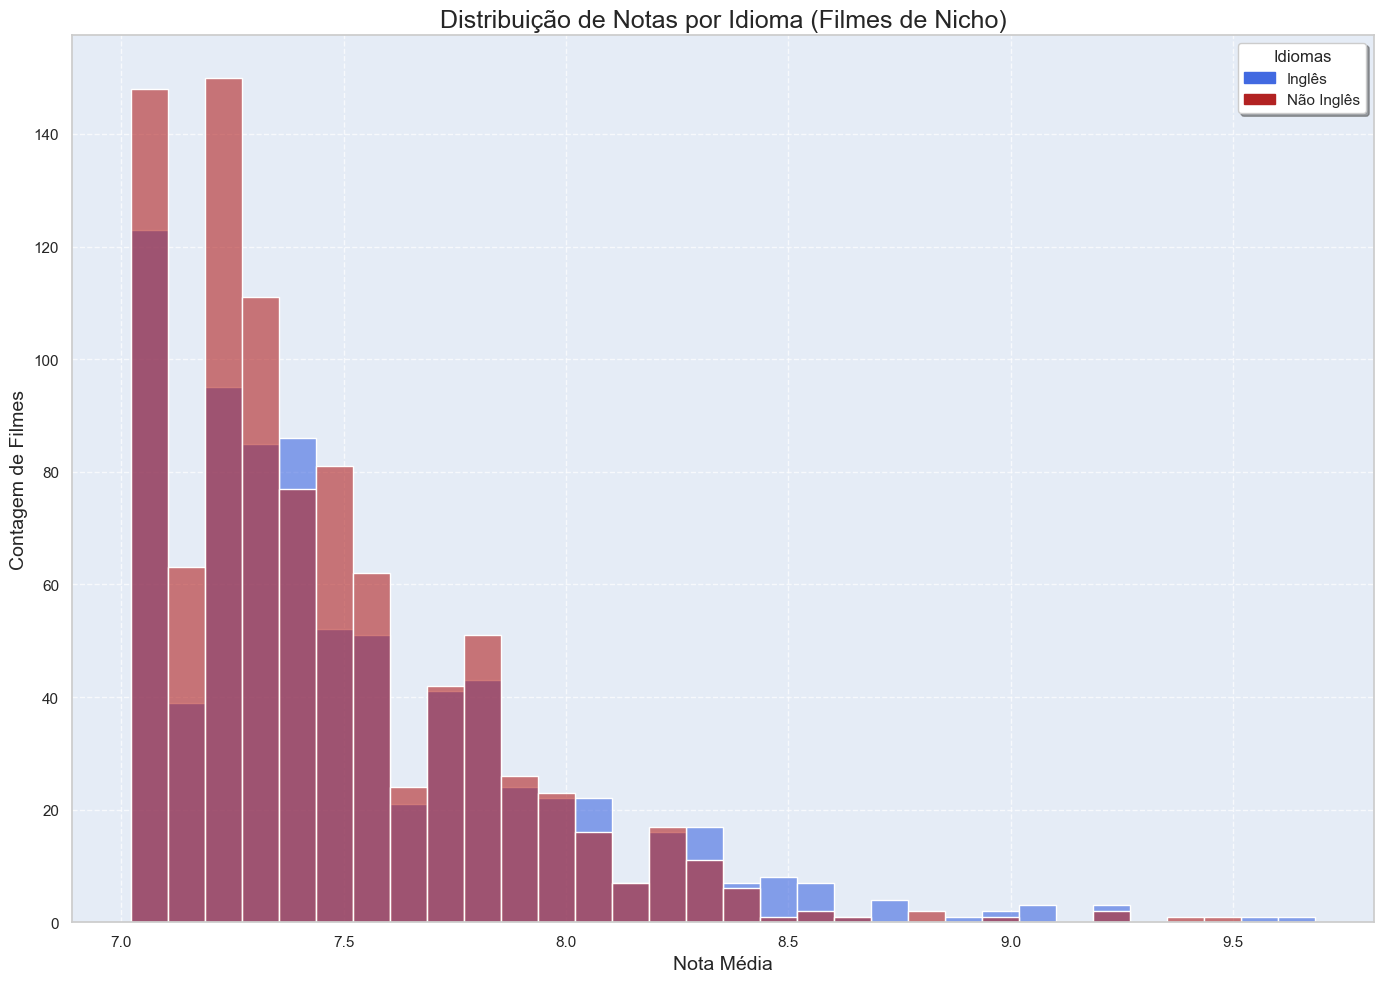

------------------------------
------------------------------
Total de filmes:      1708
Filmes em Inglês:     782 (45.8%)
Filmes Estrangeiros:  926 (54.2%)
------------------------------


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

filmes_concentracao = df_aux[
    (df_aux['vote_average'] > 7.0) &
    (df_aux['vote_count'] < media_votos) &
    (df_aux['vote_count'] > 15) &
    (df_aux['runtime'] > 0)
].copy()

filmes_concentracao['idioma_grupo'] = filmes_concentracao['original_language'].apply(
    lambda x: 'Inglês' if x == 'en' else 'Não Inglês'
)

plt.figure(figsize=(14, 10))

ax = sns.histplot(
    data=filmes_concentracao,
    x='vote_average',
    hue='idioma_grupo',
    palette={'Inglês': 'royalblue', 'Não Inglês': 'firebrick'},
    alpha=0.6,
    element='bars', 
    stat='count',
    edgecolor=None 
)

ax.set_facecolor('#e5ecf6') 

plt.title('Distribuição de Notas por Idioma (Filmes de Nicho)', fontsize=18) 
plt.xlabel('Nota Média', fontsize=14) 
plt.ylabel('Contagem de Filmes', fontsize=14) 

english_patch = mpatches.Patch(color='royalblue', label='Inglês')
non_english_patch = mpatches.Patch(color='firebrick', label='Não Inglês')

plt.legend(handles=[english_patch, non_english_patch], title='Idiomas', loc='upper right', frameon=True, shadow=True) 

plt.grid(True, color='white', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()

contagem_grupos = filmes_concentracao['idioma_grupo'].value_counts()
total = len(filmes_concentracao)
ingles = contagem_grupos.get('Inglês', 0)
estrangeiros = contagem_grupos.get('Não Inglês', 0)

print("-" * 30)
print("-" * 30)
print(f"Total de filmes:      {total}")
print(f"Filmes em Inglês:     {ingles} ({ingles/total:.1%})")
print(f"Filmes Estrangeiros:  {estrangeiros} ({estrangeiros/total:.1%})")
print("-" * 30)
